C:\Users\popeye\anaconda3\envs\pattern_recognition\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\popeye\anaconda3\envs\pattern_recognition\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\popeye\AppData\Local\Temp\ipykernel_35132\3063101063.py:46: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\popeye\AppData\Local\Temp\ipykernel_35132\3063101063.py:46: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users

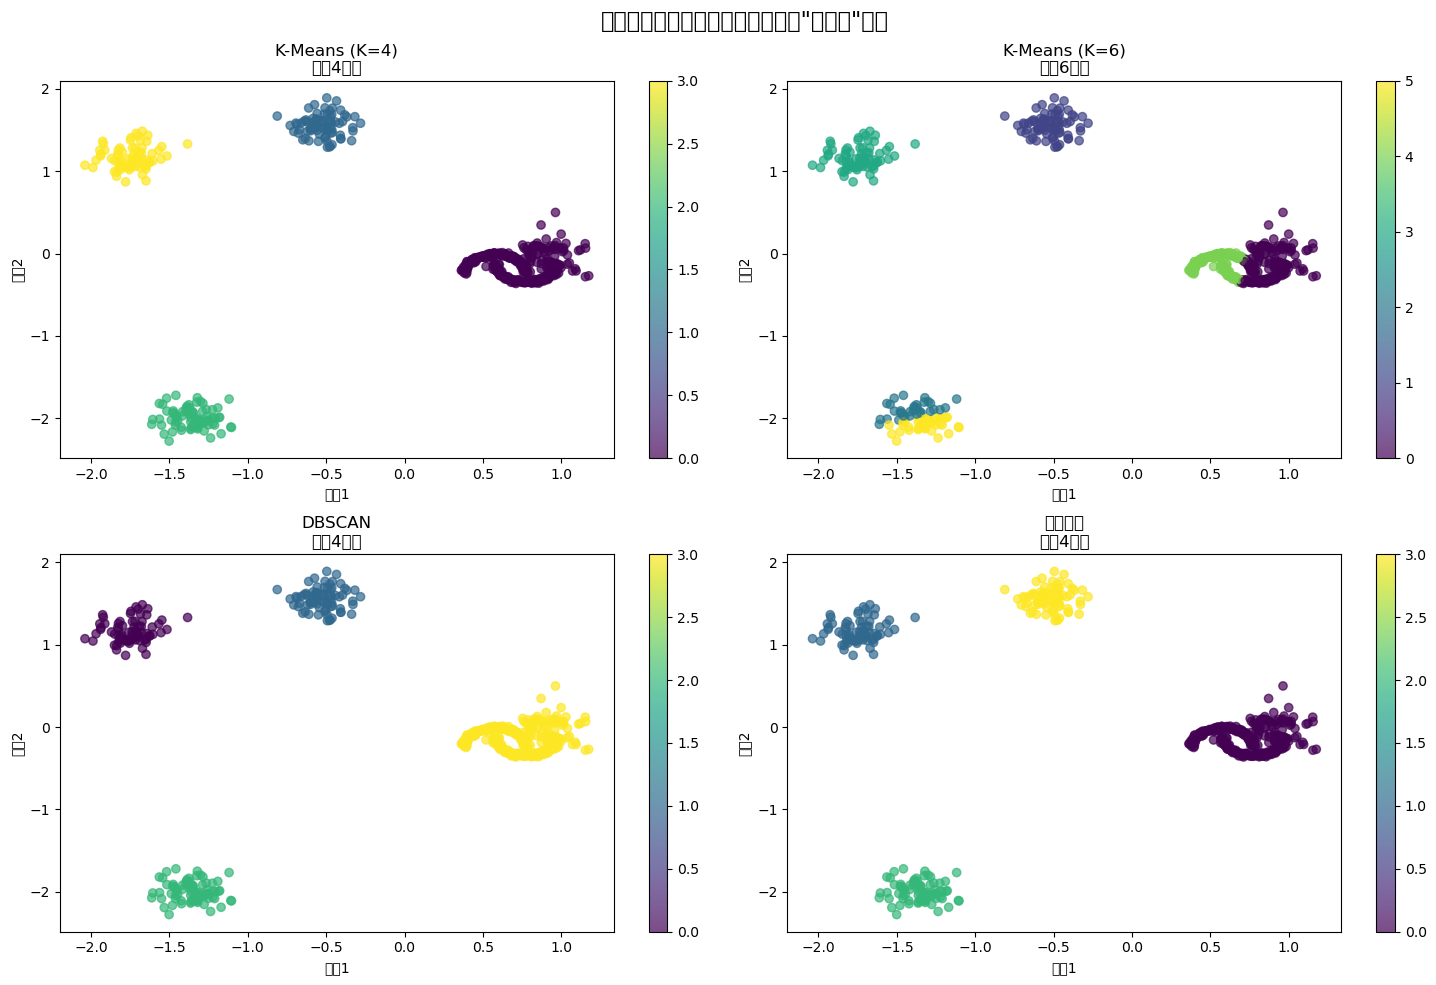

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

def explore_clustering_perspectives():
    """探索不同聚类算法对同一数据的不同"看法" """
    
    # 创建具有复杂结构的数据
    X1, y1 = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)
    X2, y2 = make_moons(n_samples=300, noise=0.05, random_state=42)
    X = np.vstack([X1, X2 + [3, 1]])
    
    # 数据标准化
    X = StandardScaler().fit_transform(X)
    
    # 应用不同的"观察透镜"
    algorithms = {
        'K-Means (K=4)': KMeans(n_clusters=4, random_state=42),
        'K-Means (K=6)': KMeans(n_clusters=6, random_state=42),
        'DBSCAN': DBSCAN(eps=0.3, min_samples=10),
        '层次聚类': AgglomerativeClustering(n_clusters=4)
    }
    
    # 可视化不同算法的"世界观"
    plt.figure(figsize=(15, 10))
    
    for i, (name, algorithm) in enumerate(algorithms.items(), 1):
        plt.subplot(2, 2, i)
        
        # 执行聚类
        if hasattr(algorithm, 'fit_predict'):
            y_pred = algorithm.fit_predict(X)
        else:
            y_pred = algorithm.fit(X).labels_
        
        # 绘制结果
        scatter = plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.7)
        plt.title(f'{name}\n发现{len(np.unique(y_pred))}个簇')
        plt.xlabel('特征1')
        plt.ylabel('特征2')
        plt.colorbar(scatter)
    
    plt.suptitle('同一数据，不同视角：聚类算法的"世界观"比较', fontsize=16)
    plt.tight_layout()
    plt.show()

# 运行探索
explore_clustering_perspectives()